In [1]:
# ==========================================
# IMPORTS
# ==========================================

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import joblib

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.preprocessing import preprocess_data
from utils.prepare_sequences import prepare_sequences

# Loading Data

In [3]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Final_data.csv"
)

df = pd.read_csv(DATA_PATH)

print("Raw data shape:", df.shape)

df.head()

Raw data shape: (8985, 15)


,Unnamed: 0,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,mon,year,Latitude,Longitude,preci,LAI,Temp
0,0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160,NaN,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333
1,1,2nd week,Maharashtra,Gadchiroli,Malaria,7,2.0,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
3,3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7,NaN,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000
4,4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14,NaN,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000


In [4]:
# ==========================================
# PREPROCESS DATA + CREATE SEQUENCES
# ==========================================

processed_df = preprocess_data(df)

X, y, metadata = prepare_sequences(
    processed_df,
    sequence_length=6
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMetadata columns:", metadata.columns.tolist())
display(metadata.head())


HEALTHSEERS - DATA PREPROCESSING

Original Shape: (8985, 15)

Disease Distribution:
Disease
Acute Diarrhoeal Disease    5126
Cholera                      666
Name: count, dtype: int64

Removed 0 invalid rows

PREPROCESSING COMPLETE

Processed Dataset Shape: (3103, 12)
Unique Locations: 180

Missing Values:
location_id    0
state_ut       0
district       0
Disease        0
year           0
week           0
Cases          0
preci          0
LAI            0
Temp           0
Latitude       0
Longitude      0
dtype: int64
X shape: (2023, 6, 4)
y shape: (2023,)

Metadata columns: ['location_id', 'target_year', 'target_week', 'target_cases']


,location_id,target_year,target_week,target_cases
0,Andhra Pradesh_Anantapur_Acute Diarrhoeal Disease,2014,26,12.0
1,Andhra Pradesh_Anantapur_Acute Diarrhoeal Disease,2015,25,71.0
2,Andhra Pradesh_Anantapur_Acute Diarrhoeal Disease,2016,22,11.0
3,Andhra Pradesh_Anantapur_Acute Diarrhoeal Disease,2021,8,30.0
4,Andhra Pradesh_Anantapur_Acute Diarrhoeal Disease,2021,9,30.0


In [5]:
# ==========================================
# TIME-AWARE SPLIT FOR EACH LOCATION
# 70% Train | 15% Validation | 15% Test
# ==========================================

# IMPORTANT:
# The sequences are generated location-wise. Splitting the entire X array
# directly can put whole locations mostly into train or test.
# Instead, split EACH location chronologically.

meta = metadata.copy().reset_index(drop=True)
meta["sequence_index"] = np.arange(len(meta))

if "location_id" not in meta.columns:
    raise ValueError(
        "metadata must contain 'location_id' for location-wise time splitting."
    )

# Sort each location by its target time.
# Adjust these candidates only if your metadata uses different names.
time_cols = []
for col in ["target_year", "target_week", "year", "week"]:
    if col in meta.columns:
        time_cols.append(col)

if not time_cols:
    raise ValueError(
        "Could not find time columns in metadata. "
        "Expected target_year/target_week or year/week."
    )

train_idx, val_idx, test_idx = [], [], []

for location, group in meta.groupby("location_id", sort=False):
    group = group.sort_values(time_cols)
    idx = group["sequence_index"].to_numpy()
    n = len(idx)

    # Need at least a few sequences to contribute to all sets
    if n < 3:
        continue

    train_end = max(1, int(n * 0.70))
    val_end = max(train_end + 1, int(n * 0.85))
    val_end = min(val_end, n - 1)

    train_idx.extend(idx[:train_end])
    val_idx.extend(idx[train_end:val_end])
    test_idx.extend(idx[val_end:])

# Convert indices to arrays
train_idx = np.array(train_idx)
val_idx = np.array(val_idx)
test_idx = np.array(test_idx)

# Build final splits
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

print("\nLocations represented:")
print("Train:", meta.iloc[train_idx]["location_id"].nunique())
print("Validation:", meta.iloc[val_idx]["location_id"].nunique())
print("Test:", meta.iloc[test_idx]["location_id"].nunique())


Training: (1321, 6, 4)
Validation: (310, 6, 4)
Testing: (392, 6, 4)

Locations represented:
Train: 180
Validation: 180
Test: 180


In [6]:
# ==========================================
# SCALE INPUT FEATURES
# Fit ONLY on training data
# ==========================================

feature_scaler = MinMaxScaler()

n_features = X_train.shape[2]

# Flatten time dimension temporarily for the scaler
X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

# Fit only on training data to avoid leakage
X_train_scaled = feature_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = feature_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = feature_scaler.transform(X_test_2d).reshape(X_test.shape)

print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Testing shape:", X_test_scaled.shape)


Training shape: (1321, 6, 4)
Validation shape: (310, 6, 4)
Testing shape: (392, 6, 4)


In [7]:
# ==========================================
# TRANSFORM + SCALE TARGET
# ==========================================

# Case counts are highly skewed with outbreak spikes.
# log1p makes the target distribution easier for the LSTM to learn.
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train_log.reshape(-1, 1)
).ravel()

y_val_scaled = target_scaler.transform(
    y_val_log.reshape(-1, 1)
).ravel()

y_test_scaled = target_scaler.transform(
    y_test_log.reshape(-1, 1)
).ravel()

print("Target transformation: log1p → StandardScaler")
print("y_train:", y_train_scaled.shape)
print("y_val:", y_val_scaled.shape)
print("y_test:", y_test_scaled.shape)


Target transformation: log1p → StandardScaler
y_train: (1321,)
y_val: (310,)
y_test: (392,)


In [14]:
# ==========================================
# BUILD LSTM MODEL
# ==========================================

model = Sequential()

model.add(Input(shape=(
    X_train_scaled.shape[1],
    X_train_scaled.shape[2]
)))

model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

# Huber loss is more robust to large outbreak spikes than plain MSE
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ==========================================
# TRAIN THE LSTM MODEL
# ==========================================

checkpoint_path = PROJECT_ROOT / "models" / "best_lstm.keras"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.4169 - mae: 0.7900 - val_loss: 0.4374 - val_mae: 0.8185
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4168 - mae: 0.7899 - val_loss: 0.4364 - val_mae: 0.8161
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4155 - mae: 0.7899 - val_loss: 0.4362 - val_mae: 0.8155
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4156 - mae: 0.7900 - val_loss: 0.4358 - val_mae: 0.8142
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4146 - mae: 0.7878 - val_loss: 0.4363 - val_mae: 0.8168
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4146 - mae: 0.7882 - val_loss: 0.4353 - val_mae: 0.8142
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4131 - mae: 0.7869 - val_loss: 0.4355 - val_mae: 0.8152
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4134 - mae: 0.7858 - val_loss: 0.4354 - val_mae: 0.8154
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

In [16]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_pred_scaled = model.predict(X_test_scaled)

# Undo StandardScaler
y_pred_log = target_scaler.inverse_transform(y_pred_scaled).ravel()

# Undo log1p
y_pred = np.expm1(y_pred_log)

# Case counts cannot be negative
y_pred = np.clip(y_pred, 0, None)

# y_test is already in the original case-count scale
y_actual = y_test.copy()

print("First 10 predictions:")
for actual, predicted in zip(y_actual[:10], y_pred[:10]):
    print(
        f"Actual: {actual:.2f} | "
        f"Predicted: {predicted:.2f}"
    )


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
First 10 predictions:
Actual: 30.00 | Predicted: 32.56
Actual: 11.00 | Predicted: 27.02
Actual: 32.00 | Predicted: 25.69
Actual: 12.00 | Predicted: 27.41
Actual: 42.00 | Predicted: 30.29
Actual: 35.00 | Predicted: 30.45
Actual: 67.00 | Predicted: 30.71
Actual: 9.00 | Predicted: 33.35
Actual: 38.00 | Predicted: 47.41
Actual: 42.00 | Predicted: 32.21


In [17]:
# ==========================================
# FINAL MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

# Baseline: predict the training-set mean for every test sample
baseline_pred = np.full_like(
    y_actual,
    fill_value=np.mean(y_train),
    dtype=float
)
baseline_mae = mean_absolute_error(y_actual, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_actual, baseline_pred)
)

print("=" * 45)
print("HEALTHSEERS LSTM - TEST EVALUATION")
print("=" * 45)
print(f"MAE          : {mae:.2f} cases")
print(f"RMSE         : {rmse:.2f} cases")
print(f"R²           : {r2:.4f}")
print("-" * 45)
print(f"Baseline MAE : {baseline_mae:.2f} cases")
print(f"Baseline RMSE: {baseline_rmse:.2f} cases")

# Save model and scalers for the Streamlit app
model.save(PROJECT_ROOT / "models" / "healthseers_lstm.keras")
joblib.dump(feature_scaler, PROJECT_ROOT / "models" / "feature_scaler.pkl")
joblib.dump(target_scaler, PROJECT_ROOT / "models" / "target_scaler.pkl")

print("\nSaved model and scalers in the models/ folder.")


HEALTHSEERS LSTM - TEST EVALUATION
MAE          : 36.37 cases
RMSE         : 96.77 cases
R²           : 0.0092
---------------------------------------------
Baseline MAE : 42.32 cases
Baseline RMSE: 97.33 cases

Saved model and scalers in the models/ folder.


# Training Curves

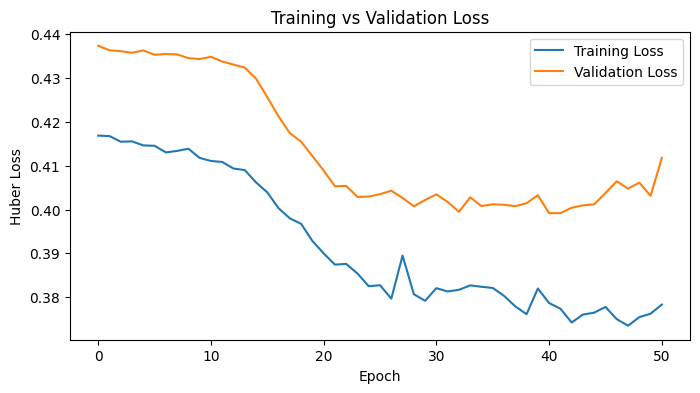

In [19]:
# ==========================================
# PLOT TRAINING CURVES
# ==========================================

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


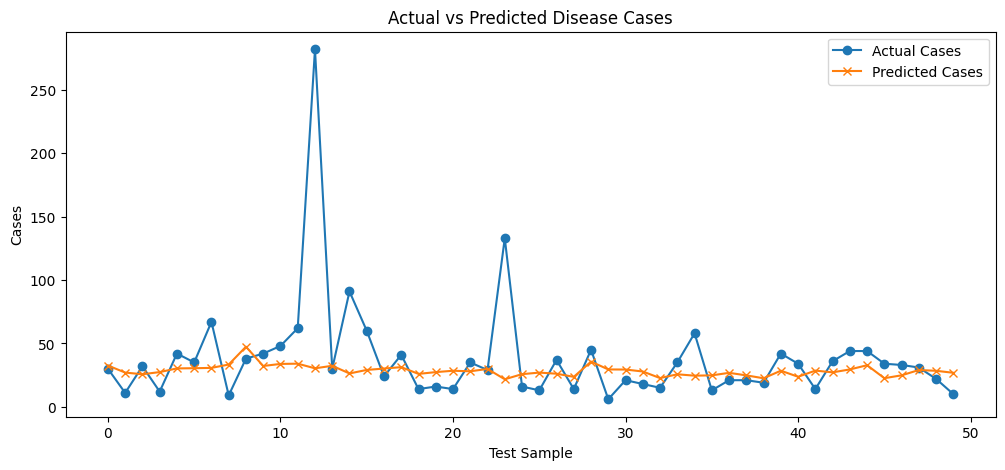

In [20]:
# ==========================================
# VISUALIZE ACTUAL VS PREDICTED
# ==========================================

n = min(50, len(y_actual))

plt.figure(figsize=(12, 5))
plt.plot(y_actual[:n], marker="o", label="Actual Cases")
plt.plot(y_pred[:n], marker="x", label="Predicted Cases")
plt.xlabel("Test Sample")
plt.ylabel("Cases")
plt.title("Actual vs Predicted Disease Cases")
plt.legend()
plt.show()
